In [198]:
# Remove all objects from the current workspace (R memory).
rm(list = ls())

# Load libraries
library("reticulate")
library(edgeR)
library(anndata)

# Use the path to your Python executable in the virtual environment
use_python("/lila/home/forsythb/.virtualenvs/r-reticulate/bin/")

# Look at where Python is located
py_config()

# Import scanpy
sc <- import("scanpy")

python:         /lila/home/forsythb/.virtualenvs/r-reticulate/bin/python
libpython:      /home/forsythb/anaconda3/lib/libpython3.8.so
pythonhome:     /lila/home/forsythb/.virtualenvs/r-reticulate:/lila/home/forsythb/.virtualenvs/r-reticulate
version:        3.8.18 (default, Sep 11 2023, 13:40:15)  [GCC 11.2.0]
numpy:          /lila/home/forsythb/.virtualenvs/r-reticulate/lib/python3.8/site-packages/numpy
numpy_version:  1.24.4

NOTE: Python version was forced by use_python() function

In [199]:
# Read in the adata
adata = sc$read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output.042224/limma/input/adata.base.h5ad')

In [127]:
# Convert AnnData to dataframe
adata_df <- adata$to_df()

In [196]:
# Convert AnnData to dataframe
adata_df <- t(adata)$to_df()

In [197]:
head(adata_df)

,KG146Li_BASE_shZFP36L2_3_AGTTAGCAGACTGAGC-1,KG146Li_BASE_shZFP36L2_3_CTGCCTATCCAAAGGG-1,KG146Li_BASE_shZFP36L2_3_CTCACTGTCCGTCACT-1,KG146Li_BASE_shZFP36L2_3_TTAGGGTCAGCTGAAG-1,KG146Li_BASE_shZFP36L2_3_CACCGTTAGGAAAGGT-1,KG146Li_BASE_shZFP36L2_3_TGTTGGATCGAGCTGC-1,KG146Li_BASE_shZFP36L2_3_TTCCTCTCAGTATTCG-1,KG146Li_BASE_shZFP36L2_3_GCACTAACACGTCTCT-1,KG146Li_BASE_shZFP36L2_3_GAAGAATCAACCCTCT-1,KG146Li_BASE_shZFP36L2_3_TACGCTCTCCTCTGCA-1,⋯,146P_BASE_shZFP36L2_4_ATGGATCCAAGACGGT-1,146P_BASE_shZFP36L2_4_GAGACCCTCTTAGTTC-1,146P_BASE_shZFP36L2_4_AGTGACTCAAGAGTTA-1,146P_BASE_shZFP36L2_4_CGCCATTAGAAACACT-1,146P_BASE_shZFP36L2_4_TTCGATTAGTGGTTAA-1,146P_BASE_shZFP36L2_4_CCCTAACTCATTCATC-1,146P_BASE_shZFP36L2_4_CGCATAACAATCTGCA-1,146P_BASE_shZFP36L2_4_TCCCAGTCACCGGAAA-1,146P_BASE_shZFP36L2_4_TTTGGAGAGTTCTACG-1,146P_BASE_shZFP36L2_4_TGAGGTTCACGGTGAA-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000
A1BG-AS1,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000
A1CF,2.014248,1.375464,0.4713504,0.9096617,1.074656,0.8881619,0.692723,0,0.707343,0.7509817,⋯,0.9875651,0.9219276,0,1.495708,0,0,0,1.931341,0.6829589,1.069121
A2M,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000
A2M-AS1,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000
A2ML1,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000


In [131]:
# Transpose
df <- t(adata_df)

In [139]:
head(df)

,KG146Li_BASE_shZFP36L2_3_AGTTAGCAGACTGAGC-1,KG146Li_BASE_shZFP36L2_3_CTGCCTATCCAAAGGG-1,KG146Li_BASE_shZFP36L2_3_CTCACTGTCCGTCACT-1,KG146Li_BASE_shZFP36L2_3_TTAGGGTCAGCTGAAG-1,KG146Li_BASE_shZFP36L2_3_CACCGTTAGGAAAGGT-1,KG146Li_BASE_shZFP36L2_3_TGTTGGATCGAGCTGC-1,KG146Li_BASE_shZFP36L2_3_TTCCTCTCAGTATTCG-1,KG146Li_BASE_shZFP36L2_3_GCACTAACACGTCTCT-1,KG146Li_BASE_shZFP36L2_3_GAAGAATCAACCCTCT-1,KG146Li_BASE_shZFP36L2_3_TACGCTCTCCTCTGCA-1,⋯,146P_BASE_shZFP36L2_4_ATGGATCCAAGACGGT-1,146P_BASE_shZFP36L2_4_GAGACCCTCTTAGTTC-1,146P_BASE_shZFP36L2_4_AGTGACTCAAGAGTTA-1,146P_BASE_shZFP36L2_4_CGCCATTAGAAACACT-1,146P_BASE_shZFP36L2_4_TTCGATTAGTGGTTAA-1,146P_BASE_shZFP36L2_4_CCCTAACTCATTCATC-1,146P_BASE_shZFP36L2_4_CGCATAACAATCTGCA-1,146P_BASE_shZFP36L2_4_TCCCAGTCACCGGAAA-1,146P_BASE_shZFP36L2_4_TTTGGAGAGTTCTACG-1,146P_BASE_shZFP36L2_4_TGAGGTTCACGGTGAA-1
A1BG,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000
A1BG-AS1,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000
A1CF,2.014248,1.375464,0.4713504,0.9096617,1.074656,0.8881619,0.692723,0,0.707343,0.7509817,⋯,0.9875651,0.9219276,0,1.495708,0,0,0,1.931341,0.6829589,1.069121
A2M,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000
A2M-AS1,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000
A2ML1,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0,0.000000,0.0000000,⋯,0.0000000,0.0000000,0,0.000000,0,0,0,0.000000,0.0000000,0.000000


In [133]:
# Define the genes, barcodes, and count matrix
counts <- as.matrix(adata$X)
counts <- t(adata$X)

In [190]:
# Define groups for contrast
group = factor(paste(adata$obs$ZFP_Expression, adata$obs$Tumor_Site, sep='_'))
length(group)
# There are different groups
# 'CTRL_Metastatic''CTRL_Primary''ZFP_KD_Metastatic''ZFP_KD_Primary'

[1] 16979

In [191]:
# Create DGEList object
d0 <- DGEList(df, group = group)

In [192]:
# Create the define matrix
design <- model.matrix(~0 + group, adata_df)

In [193]:
# Filter by expression
keep <- filterByExpr(d0, design)
d0 <- d0[keep,,keep.lib.sizes=FALSE]

In [194]:
table(keep)

keep
FALSE 
31806 

In [175]:
# Normalizes factors
d0 <- calcNormFactors(d0)

In [142]:
# Filter low-expressed genes
cutoff <- 1
drop <- which(apply(cpm(d0), 1, max) < cutoff)
d <- d0[-drop,] 
dim(d) # number of genes left

[1] 29955 16979

In [162]:
# Define the contrast matrix
contrast_matrix = makeContrasts(
    g.zfp = 'ZFP_KD_Primary - ZFP_KD_Metastatic',
    g.ctrl = 'CTRL_Primary - CTRL_Metastatic',
    levels = levels(group))

In [163]:
contrast_matrix

,g.zfp,g.ctrl
CTRL_Metastatic,0,-1
CTRL_Primary,0,1
ZFP_KD_Metastatic,-1,0
ZFP_KD_Primary,1,0


In [164]:
# Create the define matrix
design <- model.matrix(~0 + group)

In [176]:
# Limma fit model
v <- voom(d0, design, plot=T)

ERROR: Error in voom(d0, design, plot = T): Need at least two genes to fit a mean-variance trend


In [51]:
vfit = lmFit(v, design)
vfit = contrasts.fit(vfit,contrasts=contrast_matrix)
efit = eBayes(vfit)

Warning message in contrasts.fit(vfit, contrasts = contrast_matrix):
“row names of contrasts don't match col names of coefficients”


In [37]:
# Look at the results
de.summary = summary(decideTests(efit,p.value=0.01,lfc=0))
g_zfp = topTable(efit,coef="g.zfp", n=Inf,sort.by="p")
g_ctrl = topTable(efit,coef="g.ctrl", n=Inf,sort.by="p")

In [40]:
de.summary

       g.zfp g.ctrl
Down    3083  21380
NotSig  2687   7093
Up     26036   3333

In [ ]:
import scanpy as sc
import pandas as pd 
import seaborn as sns 
import random 
import numpy as np
import tqdm
import anndata as ad
import scipy
from scipy.sparse import csr_matrix
from glob import glob

In [2]:
import rpy2.rinterface_lib.callbacks
# import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

# sc.settings.verbosity = 0
# rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
# anndata2ri.activate()

%load_ext rpy2.ipython

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

def volcano_plot(df, log_fold_change_col, p_value_col, significance_level=0.05, fold_change_threshold=np.log2(1.5), top_n=20, highlight_genes=None, filename=None, label=False):
    """
    Creates a volcano plot.

    :param df: DataFrame containing the data
    :param log_fold_change_col: Column name of the log fold changes
    :param p_value_col: Column name of the adjusted p-values
    :param significance_level: Significance level for coloring, default is 0.05
    :param fold_change_threshold: Fold change threshold for significance, default is log2(1.5)
    :param top_n: Number of top differentially expressed genes to annotate, default is 10
    :param highlight_genes: List of specific genes to highlight, default is None
    """

    # Create a new column 'significant' based on adjusted p-value and fold change
    plt.figure(figsize=(10, 6))
    
    # Separate significant and non-significant data
    significant = df[(df[p_value_col] < significance_level) & (np.abs(df[log_fold_change_col]) > fold_change_threshold)]
    non_significant = df[~((df[p_value_col] < significance_level) & (np.abs(df[log_fold_change_col]) > fold_change_threshold))]

    # Plot non-significant genes
    plt.scatter(non_significant[log_fold_change_col], -np.log10(non_significant[p_value_col]), c='darkgrey')

    # Plot overexpressed genes
    plt.scatter(significant[significant[log_fold_change_col] > 0][log_fold_change_col], -np.log10(significant[significant[log_fold_change_col] > 0][p_value_col]), c='orangered')

    # Plot underexpressed genes
    plt.scatter(significant[significant[log_fold_change_col] < 0][log_fold_change_col], -np.log10(significant[significant[log_fold_change_col] < 0][p_value_col]), c='steelblue')



    # Draw dashed lines for significance threshold
    plt.axhline(y=-np.log10(significance_level), linestyle='--', color='grey')
    plt.axvline(x=fold_change_threshold, linestyle='--', color='grey')
    plt.axvline(x=-fold_change_threshold, linestyle='--', color='grey')

    # Annotate the top_n differentially expressed genes
    texts = []
    if top_n > 0:
        df['neg_log_p'] = -np.log10(df[p_value_col])
        top_genes = df.nlargest(top_n, 'neg_log_p')
        for index, row in top_genes.iterrows():
            texts.append(plt.text(row[log_fold_change_col], row['neg_log_p'], index, fontsize=14))
        # Remove the temporary column
        df.drop('neg_log_p', axis=1, inplace=True)

    # Highlight specific genes if provided
    if highlight_genes is not None:
        for gene in highlight_genes:
            try:
                row = df.loc[gene]
                plt.scatter(row[log_fold_change_col], -np.log10(row[p_value_col]), color='green')
                if label==True:
                    texts.append(plt.text(row[log_fold_change_col], -np.log10(row[p_value_col]), gene, fontsize=14, color='black'))
            except: pass

    # Automatically adjust the labels to prevent overlap
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', alpha=0.5), avoid_self=True, force_text=(.3,1))

    plt.title('Volcano Plot')
    plt.xlabel('Log Fold Change')
    plt.ylabel('-Log10(Adjusted p-value)')
    plt.show()

    if filename:
        plt.savefig(filename)


## limma

In [4]:
# obs_d =pd.read_csv('/data/peer/for_swanand/HTA.frozen_plasticity/HTA.frozen_plasticity.combined.120122/analysis/DEG_analysis/pbulks/obs.csv', index_col=0)

# obs_d

In [44]:
# columns_to_convert =['Transformed', 'Triple_mutant', 'Metastasis'
#                      , 'Chemo', 'IO', 'TKI','EGFR','PDX', 'EGFR_wt']
# obs_d[columns_to_convert] = obs_d[columns_to_convert].astype(int)
# obs_d.to_csv('/data/peer/for_swanand/HTA.frozen_plasticity/HTA.frozen_plasticity.combined.120122/analysis/DEG_analysis/pbulks/obs.csv')

In [4]:
%%R
# library(DESeq2)
library(dplyr)
library('Matrix')
library(tibble)
library(zoo)
library(stringr)
library(lubridate)

library(tibble)
library(limma)
library(rhdf5)
library(preprocessCore)
library(edgeR)

out_dir = '/data/peer/for_swanand/HTA.frozen_plasticity/HTA.frozen_plasticity.combined.120122/analysis/DEG_analysis/'
dir.create(paste0(out_dir,'limma.transform/'))

R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


R[write to console]: 
Attaching package: ‘zoo’


R[write to console]: The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


R[write to console]: 
Attaching package: ‘lubridate’


R[write to console]: The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [6]:
%%R
fn='/data/peer/for_swanand/HTA.frozen_plasticity/HTA.frozen_plasticity.combined.120122/analysis/DEG_analysis/pbulks_EGFRm.vs.TripMut.NSCLC/obs.csv'
obs_df<-read.csv(fn, row.names=1)


obs_df$condition = factor(obs_df$Triple_mutant)

(obs_df)


                      doublet          sample batch outlier mt_outlier
PM-1541_HPOST10_False       0 PM-1541_HPOST10     8   False      False
PM-1541_HPOST12_False       0 PM-1541_HPOST12     5   False      False
PM-1541_HPOST9_False        0  PM-1541_HPOST9    20   False      False
PM-1577_HPOST17_False       0 PM-1577_HPOST17    15   False      False
PM-1577_HPOST19_False       0 PM-1577_HPOST19    21   False      False
PM-1595_HPOST21_False       0 PM-1595_HPOST21    32   False      False
PM-1595_HPOST22_False       0 PM-1595_HPOST22    23   False      False
PM-1595_HPOST23_False       0 PM-1595_HPOST23    17   False      False
PM-1595_HPOST24_False       0 PM-1595_HPOST24    14   False      False
PM-1596_HPOST29_False       0 PM-1596_HPOST29    30   False      False
PM-1637_HPOST34_False       0 PM-1637_HPOST34    46   False      False
PM-1559_HPOST14_True        0 PM-1559_HPOST14    49   False      False
PM-1595_HPOST25_True        0 PM-1595_HPOST25    42   False      False
PM-159

In [7]:
%%R

g = readLines('/data/peer/for_swanand/HTA.frozen_plasticity/HTA.frozen_plasticity.combined.120122/analysis/DEG_analysis/pbulks_EGFRm.vs.TripMut.NSCLC/var.txt')

bc = readLines('/data/peer/for_swanand/HTA.frozen_plasticity/HTA.frozen_plasticity.combined.120122/analysis/DEG_analysis/pbulks_EGFRm.vs.TripMut.NSCLC/bc.txt')

data <- read.csv('/data/peer/for_swanand/HTA.frozen_plasticity/HTA.frozen_plasticity.combined.120122/analysis/DEG_analysis/pbulks_EGFRm.vs.TripMut.NSCLC/mat.csv', header = FALSE)
cts = as.matrix(data)

cts = as.matrix(cts)

##colnames = bc and rownames =g IF MAT IS ALREADY Transposed
colnames(cts) = g
rownames(cts) = bc
cts = t(cts)

cts = cts[rowSums(cts) != 0,]

obs_df = obs_df[colnames(cts),]

obs_df = obs_df %>% dplyr::filter(colSums(cts) != 0)
cts = cts[,colSums(cts) != 0]

In [9]:
%%R
print(dim(cts))
print(length(bc))
print(length(g))

[1] 25302    20
[1] 20
[1] 25302
 25302    20
[1] 20
[1] 25302


In [ ]:
# Index(['doublet', 'sample', 'batch', 'outlier', 'mt_outlier', '_scvi_batch',
#        '_scvi_labels', 'Age', 'Sex', 'Race', 'Ethnicity', 'Smoking', 'Histo',
#        'Pre-transformed', 'Transformed', 'Triple_mutant', 'Metastasis',
#        'Tissue', 'Chemo', 'IO', 'TKI', 'EGFR', 'PDX', 'EGFR_wt',
#        'psbulk_n_cells', 'psbulk_counts'],
#       dtype='object')

[1] 0
[1] 0


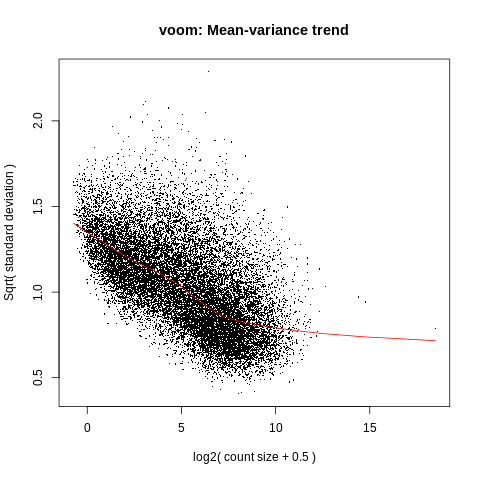

In [29]:
%%R

design <- model.matrix(~1+Tissue+condition, obs_df)

dge <- DGEList(counts=cts)
keep <- filterByExpr(dge, design)
dge <- dge[keep,,keep.lib.sizes=FALSE]
dge <- calcNormFactors(dge)


v <- voom(dge,design, plot=T)
corfit <- duplicateCorrelation(v,design,block=obs_df$sample)
print(corfit$consensus)
v <- voom(dge,design, plot=T, block=obs_df$sample, correlation = corfit$consensus)
corfit <- duplicateCorrelation(v,design,block=obs_df$sample)
print(corfit$consensus)
fit <- lmFit(v, design, block=obs_df$sample, correlation=corfit$consensus)
fit <- eBayes(fit, trend=T, robust=T)

tt = topTable(fit, coef=ncol(design), number = 30000) %>% dplyr::arrange(-logFC,P.Value)

write.table(tt, sprintf('limma.transform/EGFRm_vs_TripMut.NSCLC.limma.txt'), sep='\t', quote=F, row.names=T, col.names=NA)
write.table(tt %>% dplyr::filter(adj.P.Val < 0.1 & abs(logFC) > log2(1.5)), sprintf('limma.transform/EGFRm_vs_TripMut.NSCLC.limma.filtered.txt',out_dir), sep='\t', quote=F, row.names=T, col.names=NA)

In [30]:
limma_res=pd.read_csv('/data/peer/for_swanand/HTA.frozen_plasticity/HTA.frozen_plasticity.combined.120122/analysis/DEG_analysis/limma.transform/EGFRm_vs_TripMut.NSCLC.limma.txt', sep='\t', index_col=[0])
# limma_res['logFC']=-1*limma_res['logFC']
limma_res

,logFC,AveExpr,t,P.Value,adj.P.Val,B
KIF1A,5.707162,1.038925,5.642547,0.000027,0.049753,2.543518
IGF2,5.524672,2.242847,4.382100,0.000385,0.096362,0.258332
NPPB,5.328839,-2.611243,5.875627,0.000016,0.049753,2.303264
C6ORF15,5.294531,-2.561908,4.476186,0.000307,0.087383,0.119837
LINC01037,5.227633,-1.498105,4.738275,0.000175,0.070608,0.714024
...,...,...,...,...,...,...
TNNT1,-3.949109,2.063178,-4.385007,0.000377,0.096362,0.235879
GPNMB,-3.983874,3.556888,-2.710406,0.014613,0.305131,-3.051261
NTNG1,-4.026125,2.927868,-3.214786,0.004956,0.212754,-2.030354
KRT16,-4.305034,1.493451,-2.172409,0.043881,0.417496,-3.872098


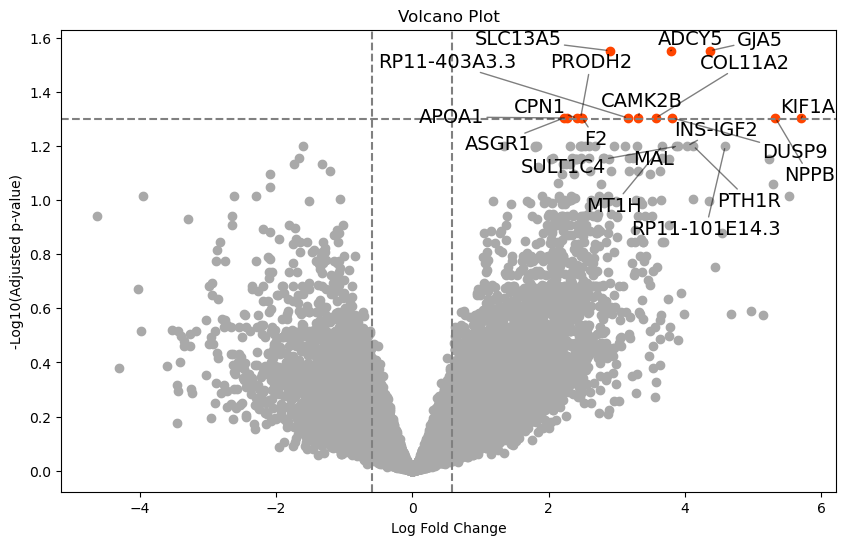

In [31]:
volcano_plot(limma_res, 'logFC', 'adj.P.Val')